# Pareto optimization of torque density, efficiency, and mass

The MDO layer turns the motor model into a multi-objective design study:
mixed continuous/discrete design variables, SPEC-style constraint strings,
and a genetic algorithm (pymoo `MixedVariableGA`) that returns only
**feasible, non-dominated** designs.

Requires the optimization extra: `pip install "axfluxmdo[opt]"`.

In [1]:
from pathlib import Path

from axfluxmdo import AxialFluxMotor, OperatingPoint
from axfluxmdo.models import AnnularModel
from axfluxmdo.optimize import compute_sensitivities, optimize_pareto
from axfluxmdo.viz import plot_pareto, plot_tornado

OUTPUT_DIR = Path(__file__).parent / "output" if "__file__" in globals() else Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

motor = AxialFluxMotor(
    outer_radius=0.08,
    inner_radius=0.025,
    air_gap=0.0008,
    pole_pairs=14,
    phases=3,
    turns_per_phase=24,
    fill_factor=0.45,
    magnet_thickness=0.004,
    back_iron_thickness=0.006,
)
op = OperatingPoint(speed_rpm=500, current_rms=25, dc_bus_voltage=48)
model = AnnularModel(n_slices=16)

baseline = model.evaluate(motor, op)
print(f"baseline: {baseline.torque_density_nm_kg:.2f} N·m/kg, η={baseline.efficiency:.4f}")

baseline: 2.36 N·m/kg, η=0.9553


## Run the Pareto study

Four design variables (one discrete), three objectives, two explicit
constraints — plus the model's built-in limits (thermal, voltage, current
density, saturation, magnet temperature), which are always enforced.

This budget (pop 48 × 25 generations ≈ 1200 evaluations) runs in seconds;
scale to `pop_size=100, n_gen=80` for production-quality fronts.

In [2]:
study = optimize_pareto(
    motor,
    op,
    variables={
        "outer_radius": (0.05, 0.12),
        "pole_pairs": [8, 10, 12, 14, 16, 18, 20],
        "air_gap": (0.0005, 0.0015),
        "fill_factor": (0.30, 0.60),
    },
    objectives=["maximize_torque_density", "maximize_efficiency", "minimize_mass"],
    constraints=["winding_temp_c < 140", "electrical_frequency_hz < 1000"],
    model=model,
    pop_size=48,
    n_gen=25,
    seed=42,
)
print(study.summary())

ParetoStudy: 48 feasible non-dominated designs (pop=48, gen=25, seed=42)
  maximize_torque_density: 2.209 … 2.727
  maximize_efficiency: 0.891 … 0.9805
  minimize_mass: 1.135 … 9.013


## The Pareto front

Three objectives render as x/y position plus color. Every plotted point is
feasible — the front *is* the design space worth arguing about.

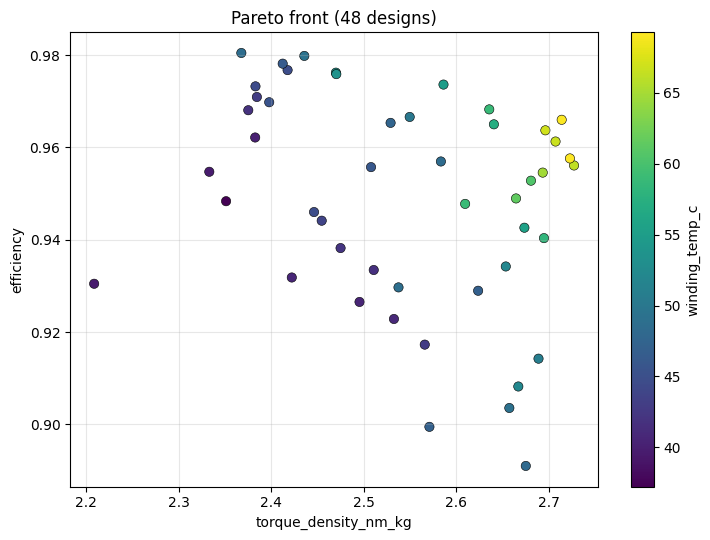

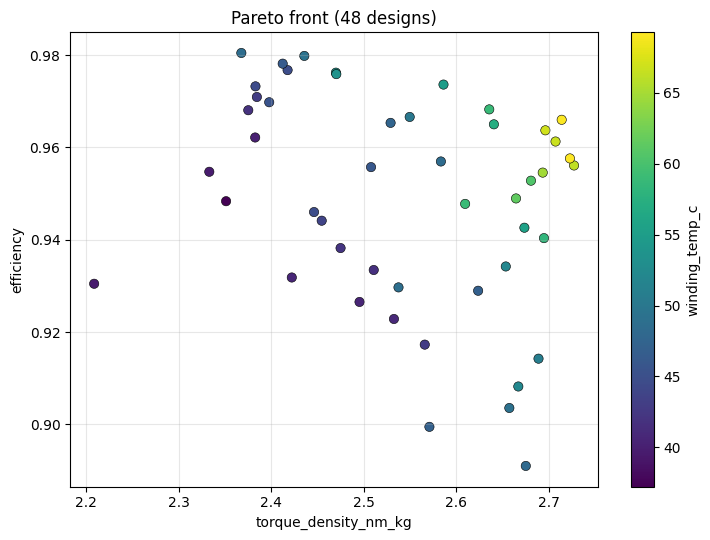

In [3]:
fig = plot_pareto(study, x="torque_density", y="efficiency", color="winding_temp_c")
fig.savefig(OUTPUT_DIR / "05_pareto_front.png", dpi=150, bbox_inches="tight")
fig

## Never optimize torque density alone

The torque-density champion and the efficiency champion are different
machines. Picking a design means choosing a position on the front — and the
constraint margins show what you give up.

In [4]:
for label in ("torque_density", "efficiency"):
    idx = study.best(label)
    r = study.results[idx]
    x = study.X[idx]
    print(f"--- best {label} ---")
    print(
        f"  design: r_o={x['outer_radius'] * 1e3:.1f} mm, p={x['pole_pairs']}, "
        f"gap={x['air_gap'] * 1e3:.2f} mm, fill={x['fill_factor']:.2f}"
    )
    print(
        f"  torque density {r.torque_density_nm_kg:.2f} N·m/kg | η {r.efficiency:.4f} | "
        f"mass {r.mass_kg:.2f} kg | winding {r.winding_temp_c:.0f} °C"
    )

--- best torque_density ---
  design: r_o=99.6 mm, p=20, gap=0.52 mm, fill=0.30
  torque density 2.73 N·m/kg | η 0.9561 | mass 5.42 kg | winding 66 °C
--- best efficiency ---
  design: r_o=119.6 mm, p=18, gap=0.61 mm, fill=0.60
  torque density 2.37 N·m/kg | η 0.9805 | mass 9.01 kg | winding 49 °C


## Which variables matter? (tornado chart)

One-at-a-time ±5 % sensitivities around the torque-density champion.

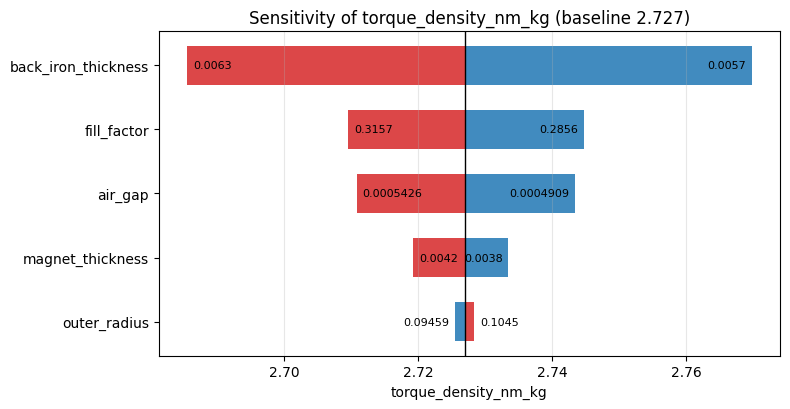

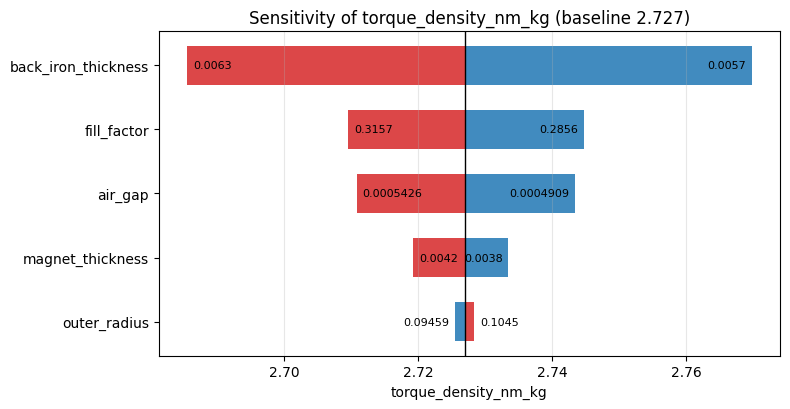

In [5]:
champion = study.motors[study.best("torque_density")]
sens = compute_sensitivities(
    champion,
    op,
    ["outer_radius", "air_gap", "fill_factor", "magnet_thickness", "back_iron_thickness"],
    output="torque_density",
    model=model,
)
fig = plot_tornado(sens)
fig.savefig(OUTPUT_DIR / "05_tornado.png", dpi=150, bbox_inches="tight")
fig

## Gradient refinement with OpenMDAO

For local polish of the continuous variables around a chosen design, the
model is also wired into OpenMDAO (SLSQP, finite-difference partials).

In [6]:
from axfluxmdo.optimize import run_openmdao_demo

refined = run_openmdao_demo(
    champion,
    op,
    variables={"outer_radius": (0.05, 0.12), "fill_factor": (0.30, 0.60)},
    objective="maximize_torque_density",
    constraints=("winding_temp_c < 140",),
    model=model,
)
before = model.evaluate(champion, op).torque_density_nm_kg
print(f"before refinement: {before:.3f} N·m/kg")
print(f"after refinement:  {refined['result']['torque_density_nm_kg']:.3f} N·m/kg")
print(f"feasible: {bool(refined['result']['feasible'])}")

Optimization terminated successfully    (Exit mode 0)
            Current function value: -2.7324472048252932
            Iterations: 2
            Function evaluations: 2
            Gradient evaluations: 2
Optimization Complete
-----------------------------------
before refinement: 2.727 N·m/kg
after refinement:  2.732 N·m/kg
feasible: True


/Users/johnhodge/Documents/code/axfluxmdo/.venv/lib/python3.12/site-packages/openmdao/core/total_jac.py:1745: DerivativesWarning:The following constraints or objectives cannot be impacted by the design variables of the problem at the current design point:
  g_2, inds=[0]
  g_6, inds=[0]

